# DiffPO Confounding Diffusion Analysis

Compares DDIM denoising trajectories between DiffPO trained on clean IHDP (`naive_full`) and
DiffPO trained on confounded IHDP (`naive_conf`).

## Setup

Loads the config and the two trained DiffPO checkpoints (clean vs. confounded IHDP), loads
both datasets, selects a 20-subject analysis subset (10 momblack==1 / 10 momblack==0), and
runs the DDIM trajectories and point-estimate samples used by the claims below.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from matplotlib.axes import Axes
from mpl_toolkits.mplot3d.axes3d import Axes3D
from scipy.stats import gaussian_kde

from src.config import Config
from src.data import load_ihdp, make_ihdp_confounded
from src.model import DiffPO, _DiffusionBase

In [5]:
CLEAN_CHECKPOINT = "checkpoints/final_model_naive_full_2026-08-03T16_21_12.pth"
CONF_CHECKPOINT = "checkpoints/final_model_naive_conf_2026-08-21T12_31_09_rep1.pth"
N_PER_GROUP = 10  # subjects per momblack group
SEED = 0
DEVICE = torch.device("cpu")

In [6]:
with open("config/ihdp.yaml") as f:
    cfg = Config.model_validate(yaml.safe_load(f))

clean_model = DiffPO(cfg.vae, cfg.diffusion)
clean_model.load_state_dict(torch.load(CLEAN_CHECKPOINT, map_location=DEVICE))
clean_model.eval()

conf_model = DiffPO(cfg.vae, cfg.diffusion)
conf_model.load_state_dict(torch.load(CONF_CHECKPOINT, map_location=DEVICE))
conf_model.eval()

print("clean_model.L:", clean_model.L, "  conf_model.L:", conf_model.L)

clean_model.L: 200   conf_model.L: 200


In [7]:
train_ds_clean, val_ds_clean, test_ds_clean, y_std = load_ihdp(
    cfg.data.path,
    replication=cfg.data.replication,
    train_ratio=cfg.data.train_ratio,
    test_ratio=cfg.data.test_ratio,
)
train_ds_conf, val_ds_conf, test_ds_conf = (
    make_ihdp_confounded(ds, effect=cfg.data.confounder_effect)
    for ds in (train_ds_clean, val_ds_clean, test_ds_clean)
)


def _clip_value(train_ds):
    if not cfg.diffusion.clip_denoised:
        return None
    y_both = _DiffusionBase._assemble_yboth(train_ds.a, train_ds.y, train_ds.y_cf)
    return 2 * y_both.abs().max().item()


clip_value_clean = _clip_value(train_ds_clean)
clip_value_conf = _clip_value(train_ds_conf)
print("clip_value_clean:", clip_value_clean, "  clip_value_conf:", clip_value_conf)

clip_value_clean: 6.018764972686768   clip_value_conf: 7.191953659057617


In [8]:
rng = np.random.default_rng(SEED)
confounder = test_ds_clean.confounder
assert confounder is not None

idx_flipped = np.flatnonzero(confounder == 1)
idx_control = np.flatnonzero(confounder == 0)
assert len(idx_flipped) >= N_PER_GROUP, f"only {len(idx_flipped)} momblack==1 test subjects"
assert len(idx_control) >= N_PER_GROUP, f"only {len(idx_control)} momblack==0 test subjects"

subset_idx = np.concatenate(
    [
        rng.choice(idx_flipped, size=N_PER_GROUP, replace=False),
        rng.choice(idx_control, size=N_PER_GROUP, replace=False),
    ]
)
momblack_t = torch.as_tensor(confounder[subset_idx])
flipped_mask = momblack_t == 1
control_mask = momblack_t == 0

x = test_ds_clean.x[subset_idx]
a_clean = test_ds_clean.a[subset_idx]
a_conf = test_ds_conf.a[subset_idx]

mu0_clean = test_ds_clean.mu0[subset_idx]
mu1_clean = test_ds_clean.mu1[subset_idx]
mu0_conf = test_ds_conf.mu0[subset_idx]
mu1_conf = test_ds_conf.mu1[subset_idx]

# momblack==0 subjects must see identical (x, a) in both conditions (built-in control group);
# momblack==1 subjects must see exactly-flipped a.
assert torch.equal(a_clean[control_mask], a_conf[control_mask])
assert torch.equal(a_conf[flipped_mask], 1.0 - a_clean[flipped_mask])
assert torch.equal(test_ds_clean.x[subset_idx], test_ds_conf.x[subset_idx])

# mu0/mu1 must also agree on the control group. Using allclose as `make_ihdp_confounded`
# round-trips mu0/mu1 through denorm()/renorm() even for momblack==0 subjects (where the
# shift itself is a mathematical no-op). That float32 round trip is not bit-exact
assert torch.allclose(mu0_clean[control_mask], mu0_conf[control_mask], atol=1e-6)
assert torch.allclose(mu1_clean[control_mask], mu1_conf[control_mask], atol=1e-6)

print(
    f"Subset: {len(subset_idx)} subjects "
    f"({int(flipped_mask.sum())} momblack==1, {int(control_mask.sum())} momblack==0)"
)

print()

Subset: 20 subjects (10 momblack==1, 10 momblack==0)



In [9]:
print("Clean dataset cross tabulation")
print(
    pd.crosstab(
        test_ds_clean.confounder[subset_idx],
        test_ds_clean.a[subset_idx],
        rownames=["momblack"],
        colnames=["treatment"],
    )
)
print()

print("Confounded dataset cross tabulation:")
print(
    pd.crosstab(
        test_ds_conf.confounder[subset_idx],
        test_ds_conf.a[subset_idx],
        rownames=["momblack"],
        colnames=["treatment"],
    )
)

Clean dataset cross tabulation
treatment  0.0  1.0
momblack           
0.0          6    4
1.0          3    7

Confounded dataset cross tabulation:
treatment  0.0  1.0
momblack           
0.0          6    4
1.0          7    3


In [10]:
torch.manual_seed(SEED)
y_init = torch.randn(len(subset_idx), 2)

y_clean_final, y_clean_traj, eps_clean_traj = clean_model.sample_ddim(
    x, a_clean, y_init=y_init, clip_val=clip_value_clean, log_trajectory=True
)
y_conf_final, y_conf_traj, eps_conf_traj = conf_model.sample_ddim(
    x, a_conf, y_init=y_init, clip_val=clip_value_conf, log_trajectory=True
)

endpoint_dist = (y_clean_final - y_conf_final).norm(dim=1)
print("Mean endpoint distance (clean vs. confound):", endpoint_dist.mean().item())
print("Endpoint distance, momblack==1:", endpoint_dist[flipped_mask].mean().item())
print("Endpoint distance, momblack==0:", endpoint_dist[control_mask].mean().item())

Mean endpoint distance (clean vs. confound): 3.3474788665771484
Endpoint distance, momblack==1: 3.580456495285034
Endpoint distance, momblack==0: 3.1145009994506836


In [11]:
K = cfg.train.K  # 50, per config/ihdp.yaml -- matches the codebase's normal eval convention

torch.manual_seed(SEED)
y0_clean, y1_clean = clean_model.sample_outcomes(x, a_clean, K=K, clip_val=clip_value_clean)
torch.manual_seed(SEED)
y0_conf, y1_conf = conf_model.sample_outcomes(x, a_conf, K=K, clip_val=clip_value_conf)

err_clean = (
    (y0_clean.mean(dim=1) - mu0_clean).abs() + (y1_clean.mean(dim=1) - mu1_clean).abs()
) / 2
err_conf = (
    (y0_conf.mean(dim=1) - mu0_conf).abs() + (y1_conf.mean(dim=1) - mu1_conf).abs()
) / 2

print("MAE clean:", err_clean.mean().item())
print("MAE confound:", err_conf.mean().item())
print("MAE clean, momblack==1:", err_clean[flipped_mask].mean().item())
print("MAE clean, momblack==0:", err_clean[control_mask].mean().item())
print("MAE confound, momblack==1:", err_conf[flipped_mask].mean().item())
print("MAE confound, momblack==0:", err_conf[control_mask].mean().item())

MAE clean: 0.7440611124038696
MAE confound: 1.4928996562957764
MAE clean, momblack==1: 0.9151965379714966
MAE clean, momblack==0: 0.5729257464408875
MAE confound, momblack==1: 1.510921597480774
MAE confound, momblack==0: 1.4748780727386475


## Claim 1: a footprint exists

Cross-evaluates each model's denoiser on the other model's trajectory to compute the
predicted-noise divergence `d_tau` (and its `a_conf`-anchored counterpart `d_tau_prime`),
then reports its size relative to the denoiser's own output norm.

In [12]:
def cross_evaluate(
    other_model: _DiffusionBase,
    y_traj: torch.Tensor,
    x_cond: torch.Tensor,
    a_cond: torch.Tensor,
) -> torch.Tensor:
    """Compute `other_model`'s eps_theta at every (y_traj[i], tau=L-1-i) pair.

    i.e. the same states the *anchor* trajectory visited, cross-evaluated on
    `other_model`'s denoiser with the anchor's own (x_cond, a_cond) held fixed.

    y_traj: (L,N,2). Returns eps: (L,N,2).
    """
    L, N, _ = y_traj.shape
    tau_grid = torch.arange(L - 1, -1, -1).unsqueeze(1).expand(L, N).reshape(-1)
    y_flat = y_traj.reshape(L * N, 2)
    x_flat = x_cond.unsqueeze(0).expand(L, N, -1).reshape(L * N, -1)
    a_flat = a_cond.unsqueeze(0).expand(L, N).reshape(-1)
    with torch.no_grad():
        eps_flat = other_model.denoiser(y_flat, tau_grid, x_flat, a_flat)
    return eps_flat.reshape(L, N, 2)


# d_tau: anchored on the clean trajectory, both terms use a_clean
eps_conf_on_clean = cross_evaluate(conf_model, y_clean_traj, x, a_clean)
d_tau = eps_conf_on_clean - eps_clean_traj

# d_tau': anchored on the confound trajectory, both terms use a_conf
eps_clean_on_conf = cross_evaluate(clean_model, y_conf_traj, x, a_conf)
d_tau_prime = eps_conf_traj - eps_clean_on_conf

# Cross-evaluated predicted-noise divergence signals
d_tau_norm = d_tau.norm(dim=-1)  # (L, N)
d_tau_prime_norm = d_tau_prime.norm(dim=-1)  # (L, N)

In [13]:
eps_clean_norm = eps_clean_traj.norm(dim=-1)  # (L, N)
eps_conf_norm = eps_conf_traj.norm(dim=-1)  # (L, N)

# Is the disagreement non-trivial relative to the size of ε_θ itself?
ratio = (d_tau_norm.mean() / eps_clean_norm.mean()).item()
ratio_prime = (d_tau_prime_norm.mean() / eps_conf_norm.mean()).item()

print(f"Mean ||d_tau|| = {d_tau_norm.mean().item():.4f}")
print(f"Mean ||eps_theta|| (clean) = {eps_clean_norm.mean().item():.4f}")
print(f"Ratio ||d_tau|| / ||eps_theta|| = {ratio:.4f}")
print()
print(f"Mean ||d_tau'|| = {d_tau_prime_norm.mean().item():.4f}")
print(f"Mean ||eps_theta|| (conf) = {eps_conf_norm.mean().item():.4f}")
print(f"Ratio ||d_tau'|| / ||eps_theta|| = {ratio_prime:.4f}")

Mean ||d_tau|| = 1.6842
Mean ||eps_theta|| (clean) = 1.0660
Ratio ||d_tau|| / ||eps_theta|| = 1.5799

Mean ||d_tau'|| = 1.6867
Mean ||eps_theta|| (conf) = 1.0820
Ratio ||d_tau'|| / ||eps_theta|| = 1.5589


`d_tau` and `d_tau_prime`: if they look similar, the disagreement is a property of the region both data manifolds share

## Claim 2: when it appears

Plots `d_tau`/`d_tau_prime` against the diffusion timestep tau, split by momblack, to see
where in the reverse trajectory the divergence is concentrated.

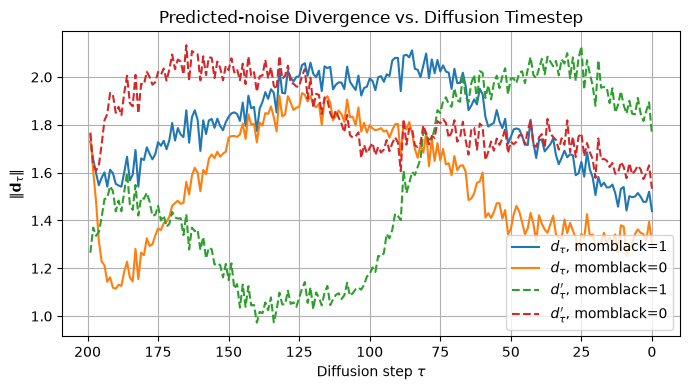

In [14]:
tau_axis = np.arange(cfg.diffusion.num_steps - 1, -1, -1)  # L-1 .. 0, matches trajectory order

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    tau_axis, d_tau_norm[:, flipped_mask].mean(dim=1).numpy(), label=r"$d_\tau$, momblack=1"
)
ax.plot(
    tau_axis, d_tau_norm[:, control_mask].mean(dim=1).numpy(), label=r"$d_\tau$, momblack=0"
)
ax.plot(
    tau_axis,
    d_tau_prime_norm[:, flipped_mask].mean(dim=1).numpy(),
    "--",
    label=r"$d_\tau'$, momblack=1",
)
ax.plot(
    tau_axis,
    d_tau_prime_norm[:, control_mask].mean(dim=1).numpy(),
    "--",
    label=r"$d_\tau'$, momblack=0",
)
ax.set_xlim(ax.get_xlim()[::-1])  # tau: L -> 0
ax.set_xlabel(r"Diffusion step $\tau$")
ax.set_ylabel(r"$\|\mathbf{d}_\tau\|$")
ax.set_title("Predicted-noise Divergence vs. Diffusion Timestep")
ax.legend()
ax.grid()
fig.tight_layout()
fig.savefig("images/confounding_divergence_vs_tau.png", dpi=150)
plt.show()

## Claim 3: does it predict harm?

Plots per-subject divergence against the confound model's point-estimate error against
ground truth, split by momblack, to check whether a larger footprint corresponds to worse
causal-effect estimates.

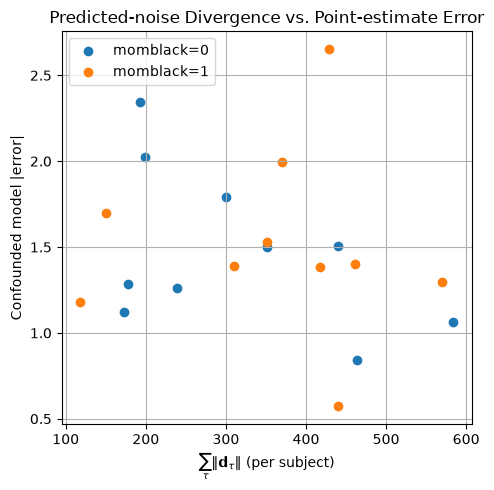

Pearson correlation, divergence vs. error: -0.2170


In [15]:
subject_divergence = d_tau_norm.sum(dim=0)  # (N,) -- sum_tau ||d_tau|| per subject

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    subject_divergence[control_mask].numpy(),
    err_conf[control_mask].numpy(),
    label="momblack=0",
)
ax.scatter(
    subject_divergence[flipped_mask].numpy(),
    err_conf[flipped_mask].numpy(),
    label="momblack=1",
)
ax.set_xlabel(r"$\sum_\tau \|\mathbf{d}_\tau\|$ (per subject)")
ax.set_ylabel("Confounded model |error|")  # vs ground truth
ax.set_title("Predicted-noise Divergence vs. Point-estimate Error")
ax.legend()
ax.grid()
fig.tight_layout()
fig.savefig("images/confounding_divergence_vs_error.png", dpi=150)
plt.show()

corr = np.corrcoef(subject_divergence.numpy(), err_conf.numpy())[0, 1]
print(f"Pearson correlation, divergence vs. error: {corr:.4f}")

## Field + density visualisation (item 1)

For one momblack==1 and one momblack==0 subject, plots each model's denoising score field
alongside a KDE density surface of y_tau at several snapshot taus. Note: the density
surfaces are built from the stochastic DDPM sampler (`density_samples`), not DDIM as in the
intro above -- a single deterministic DDIM trajectory can't produce a distribution, only
DDPM's independent stochastic draws can.

In [16]:
L = cfg.diffusion.num_steps
SNAPSHOT_TAUS = [L - 1, 3 * L // 4, L // 2, L // 4, 0]
DENSITY_K = 300
GRID_N = 40
GRID_RANGE = 4.0  # y0, y1 span, in normalised outcome units

subject_flipped = int(np.flatnonzero(flipped_mask.numpy())[0])
subject_control = int(np.flatnonzero(control_mask.numpy())[0])


def tau_to_traj_index(tau: int, L: int) -> int:
    """Trajectory index i logs tau = L-1-i (see _ddim_reverse/_ddpm_reverse docstrings)."""
    return (L - 1) - tau


def eps_grid(
    model: _DiffusionBase,
    tau: int,
    x_subj: torch.Tensor,
    a_subj: torch.Tensor,
    grid_n: int = GRID_N,
    grid_range: float = GRID_RANGE,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """`model`'s eps_theta on a (grid_n, grid_n) grid of y=(y0,y1) at fixed tau.

    This is for one subject.
    """
    lin = torch.linspace(-grid_range, grid_range, grid_n)
    Y0, Y1 = torch.meshgrid(lin, lin, indexing="xy")
    y_grid = torch.stack([Y0.reshape(-1), Y1.reshape(-1)], dim=1)  # (grid_n**2, 2)
    n = y_grid.shape[0]

    # Same (tau, x, a) for all grid points
    tau_t = torch.full((n,), tau, dtype=torch.long)
    x_rep = x_subj.unsqueeze(0).expand(n, -1)
    a_rep = a_subj.unsqueeze(0).expand(n)

    # Get the predicted noise [eps_y(0), eps_y(1)] for each grid point
    with torch.no_grad():
        eps = model.denoiser(y_grid, tau_t, x_rep, a_rep)

    return (
        Y0.numpy(),
        Y1.numpy(),
        eps[:, 0].reshape(grid_n, grid_n).numpy(),
        eps[:, 1].reshape(grid_n, grid_n).numpy(),
    )

In [17]:
def density_samples(
    model: _DiffusionBase,
    tau: int,
    x_subj: torch.Tensor,
    a_subj: torch.Tensor,
    clip_val: float,
    seed: int,
    K: int = DENSITY_K,
) -> torch.Tensor:
    """K independent stochastic reverse-trajectory samples of y_tau, for one subject."""
    torch.manual_seed(seed)

    x_rep = x_subj.unsqueeze(0).expand(K, -1)
    a_rep = a_subj.unsqueeze(0).expand(K)
    with torch.no_grad():
        _, y_traj, _ = model._ddpm_reverse(
            K, x_rep, a_rep, torch.device("cpu"), clip_val=clip_val, log_trajectory=True
        )
    return y_traj[tau_to_traj_index(tau, model.L)]  # (K, 2)


def kde_surface(
    samples: torch.Tensor, grid_n: int = GRID_N, grid_range: float = GRID_RANGE
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Fit a 2D Gaussian KDE to `samples` and evaluate it on a regular grid.

    `samples`: (K, 2) cloud of y=(y0,y1) points, e.g. y_tau collected from K stochastic
    reverse trajectories at one snapshot tau.

    Returns (Y0, Y1, Z), each (grid_n, grid_n): the meshgrid coordinates spanning
    [-grid_range, grid_range]^2, and the estimated density p_hat_tau(y) at each node,
    aligned for ax.plot_surface(Y0, Y1, Z).
    """
    kde = gaussian_kde(samples.numpy().T)
    lin = np.linspace(-grid_range, grid_range, grid_n)
    Y0, Y1 = np.meshgrid(lin, lin)
    Z = kde(np.vstack([Y0.ravel(), Y1.ravel()])).reshape(grid_n, grid_n)
    return Y0, Y1, Z


def plot_field_density(
    model: _DiffusionBase,
    tau: int,
    x_subj: torch.Tensor,
    a_subj: torch.Tensor,
    clip_val: float,
    title: str,
    ax: Axes3D,
    seed: int,
):
    """Plot a KDE density surface + score quiver projected on the axes floor."""
    samples = density_samples(model, tau, x_subj, a_subj, clip_val, seed)

    # kde_surface and eps_grid build the identical GRID_N x GRID_N lattice over
    # [-GRID_RANGE, GRID_RANGE]^2, so the coordinate meshes coincide.
    # TODO: refactor - build the grid once and pass it to both functions
    y0_grid, y1_grid, p_hat = kde_surface(samples)
    _, _, eps0, eps1 = eps_grid(model, tau, x_subj, a_subj)

    scale = (1.0 - model.alpha_bar_sched[tau]).clamp(min=1e-15).sqrt().item()
    score0, score1 = -eps0 / scale, -eps1 / scale  # the one place this notebook uses the score

    ax.plot_surface(y0_grid, y1_grid, p_hat, cmap="viridis", alpha=0.8)
    floor_z = p_hat.min() - 0.1 * (p_hat.max() - p_hat.min() + 1e-8)
    ax.quiver(
        y0_grid,
        y1_grid,
        np.full_like(y0_grid, floor_z),
        score0,
        score1,
        np.zeros_like(score0),
        length=0.3,
        normalize=True,
        color="black",
    )
    ax.set_title(title)
    ax.set_xlabel(r"$y_0$")
    ax.set_ylabel(r"$y_1$")
    ax.set_zlabel(r"$\hat p_\tau(y)$")

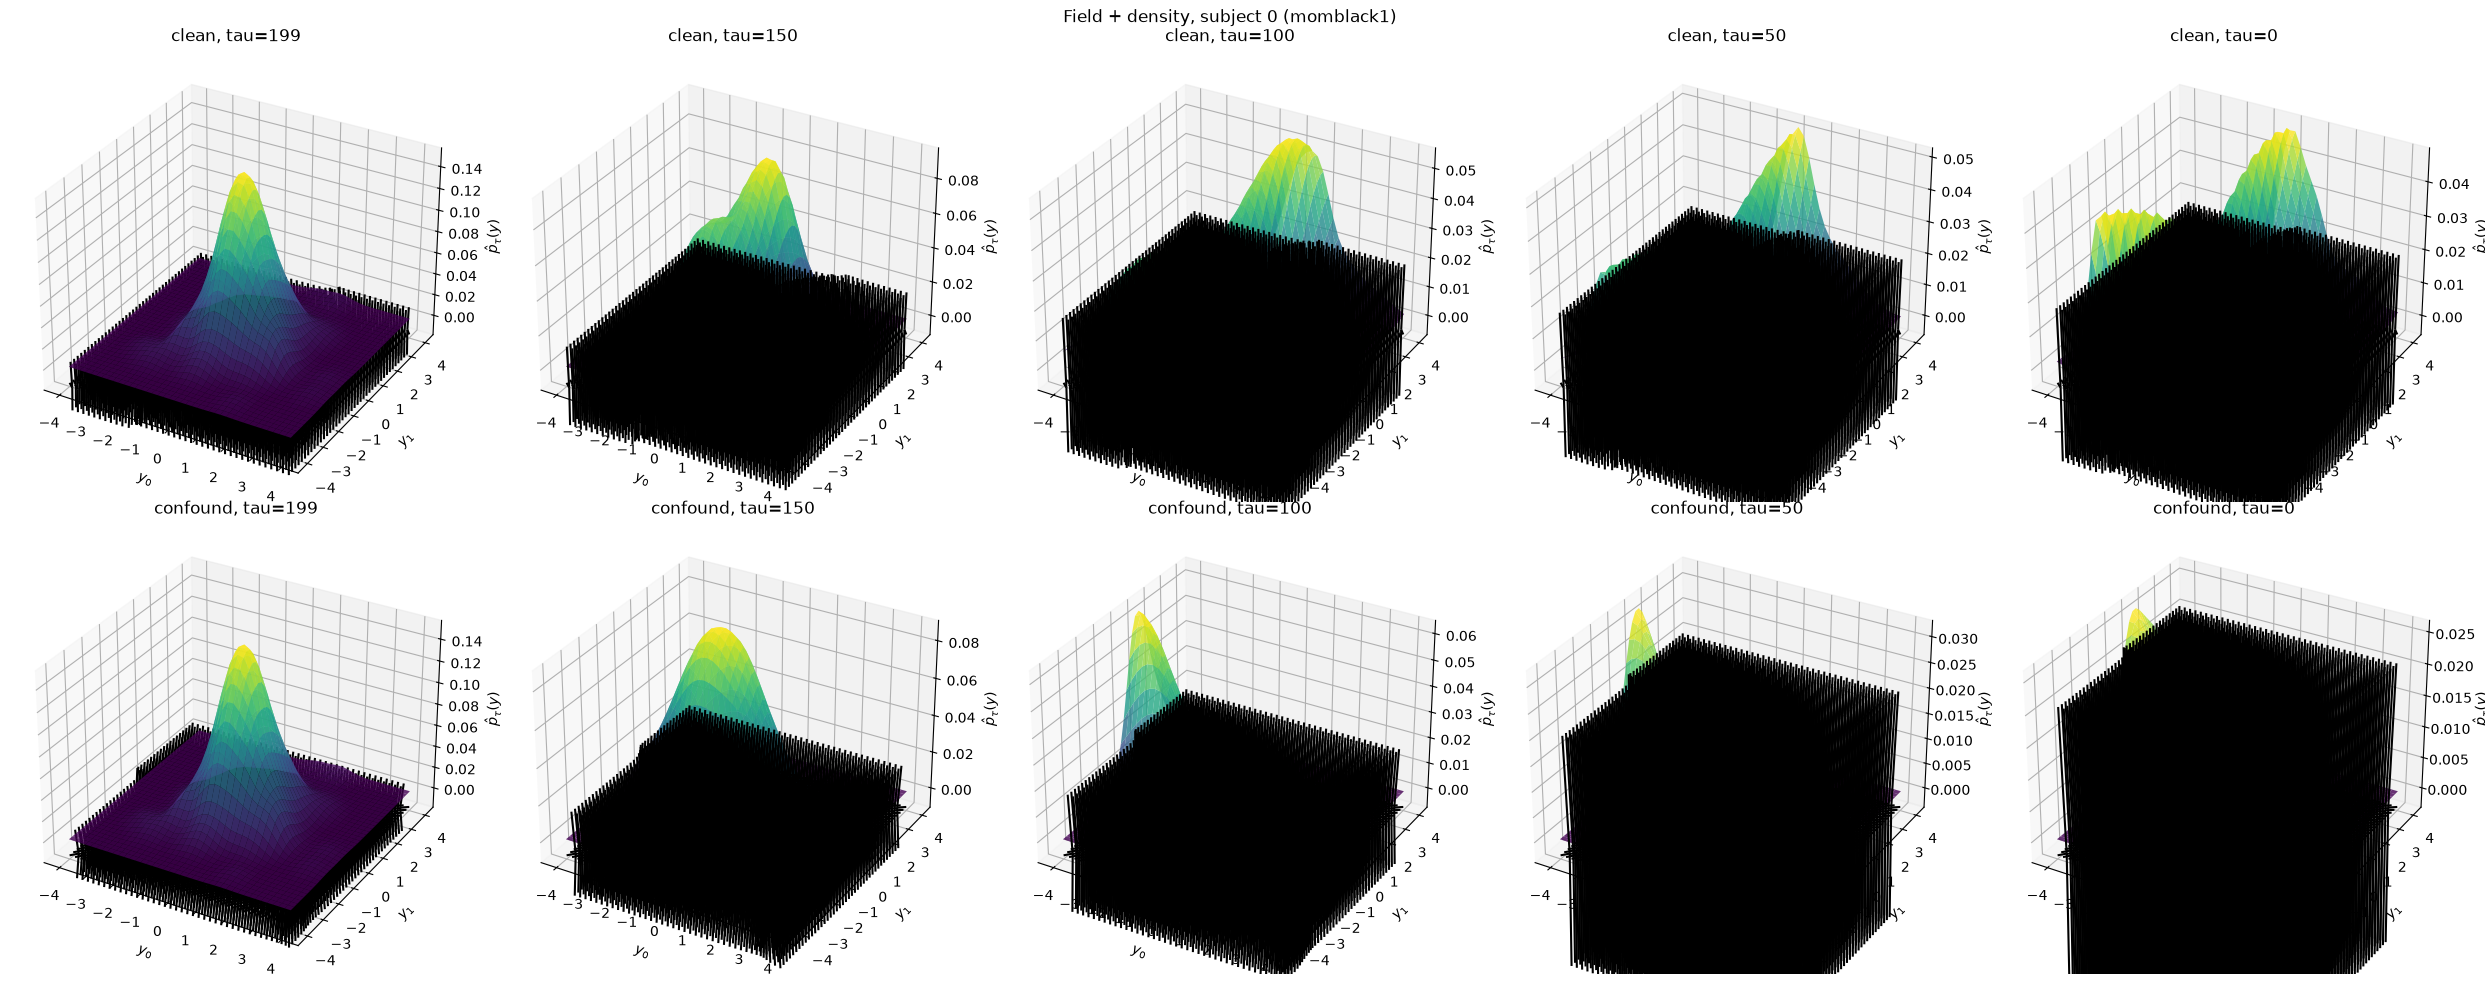

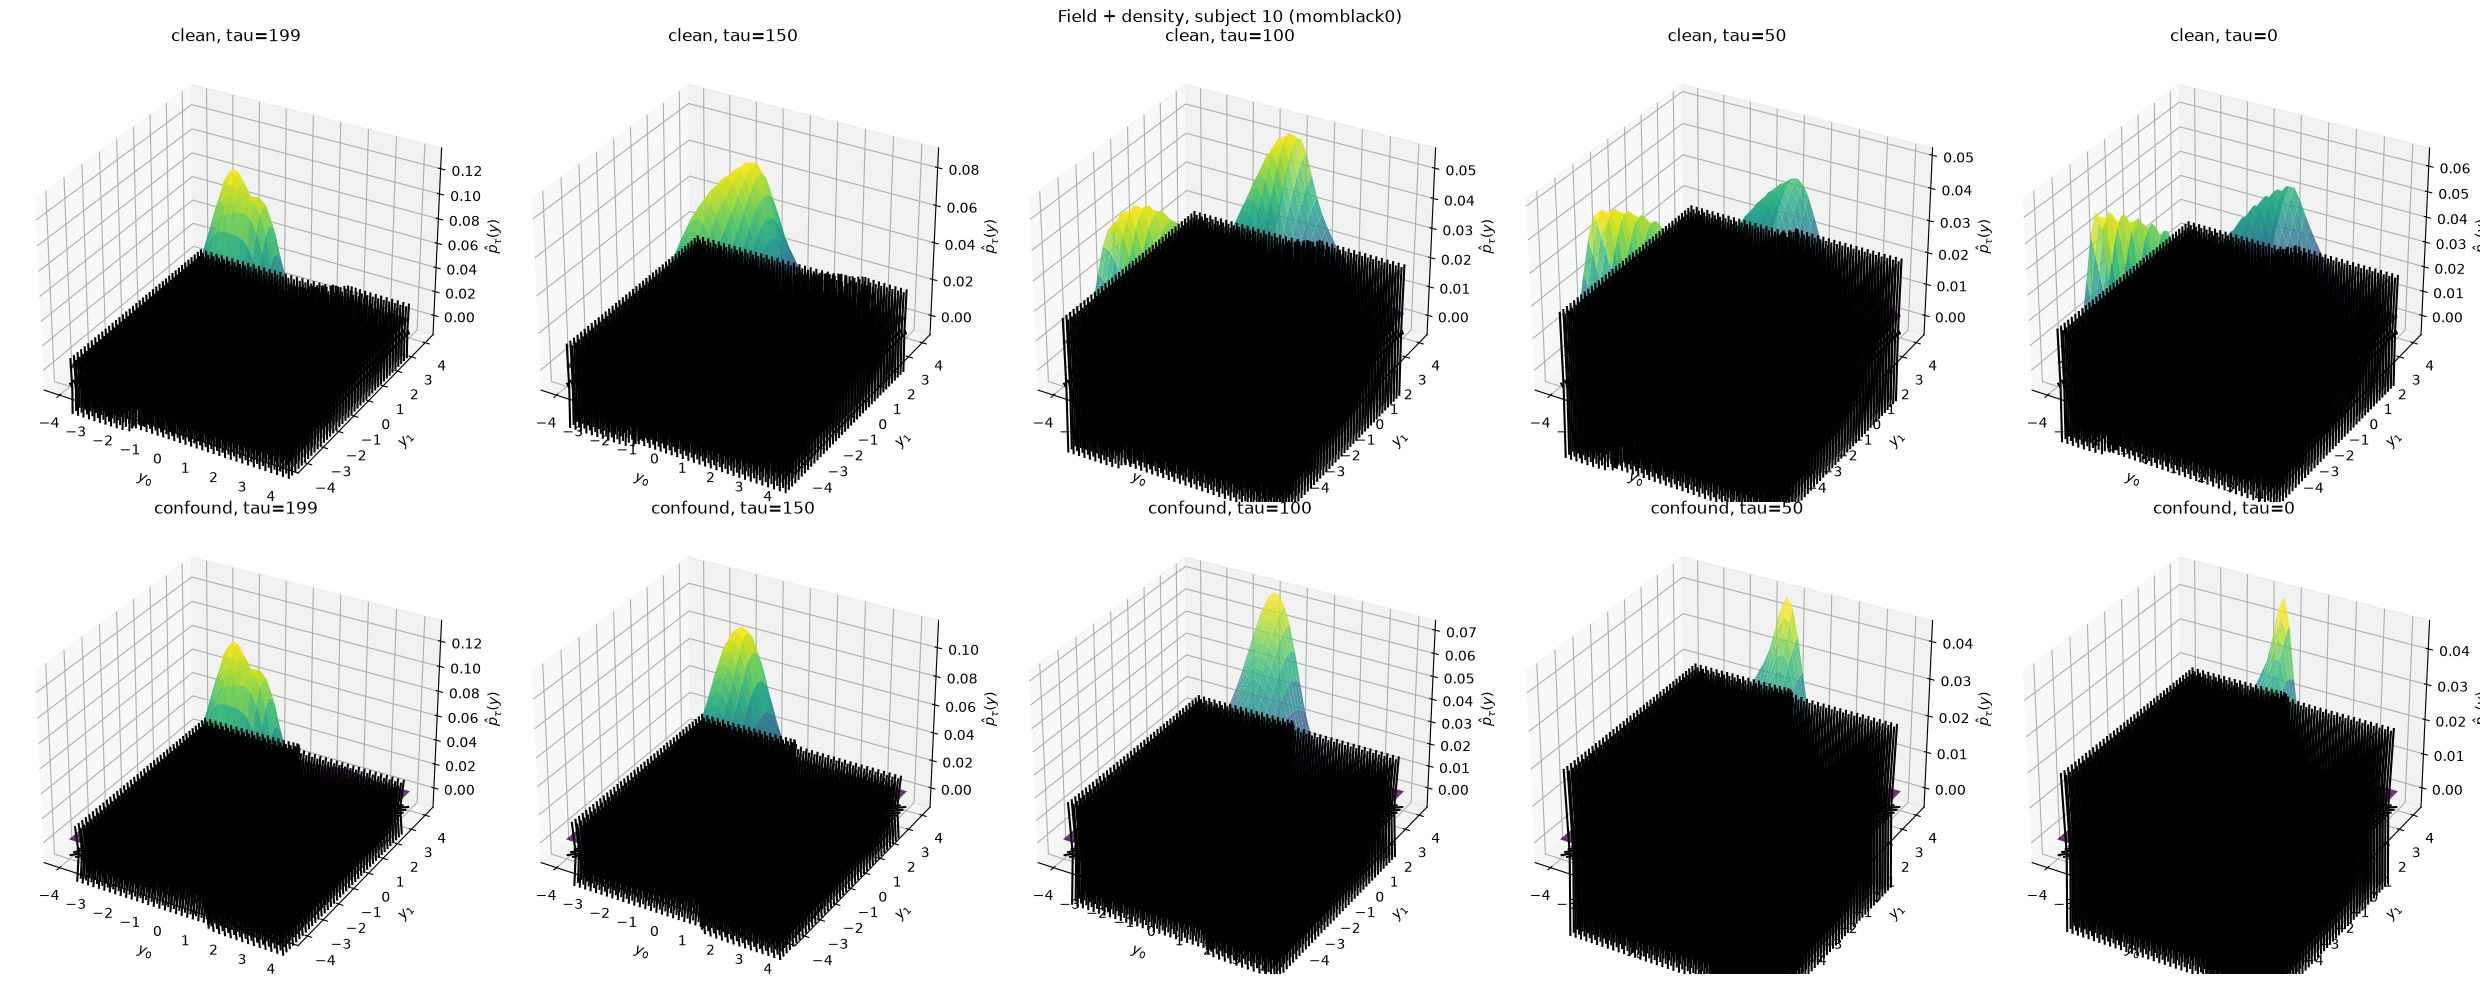

In [18]:
for subj_idx, subj_label in [(subject_flipped, "momblack1"), (subject_control, "momblack0")]:
    x_subj, a_clean_subj, a_conf_subj = x[subj_idx], a_clean[subj_idx], a_conf[subj_idx]

    fig = plt.figure(figsize=(5 * len(SNAPSHOT_TAUS), 10))
    for col, tau in enumerate(SNAPSHOT_TAUS):
        panel_seed = SEED + 100 * subj_idx + col

        ax_clean = fig.add_subplot(2, len(SNAPSHOT_TAUS), col + 1, projection="3d")
        plot_field_density(
            clean_model,
            tau,
            x_subj,
            a_clean_subj,
            clip_value_clean,
            f"clean, tau={tau}",
            ax_clean,
            panel_seed,
        )

        ax_conf = fig.add_subplot(
            2, len(SNAPSHOT_TAUS), len(SNAPSHOT_TAUS) + col + 1, projection="3d"
        )
        plot_field_density(
            conf_model,
            tau,
            x_subj,
            a_conf_subj,
            clip_value_conf,
            f"confound, tau={tau}",
            ax_conf,
            panel_seed,
        )

    fig.suptitle(f"Field + density, subject {subj_idx} ({subj_label})")
    fig.tight_layout()
    fig.savefig(f"images/confounding_field_density_{subj_label}.png", dpi=150)
    plt.show()

## Difference field visualisation (item 2)

Plots the standalone difference field d_tau(y) = eps_conf(y) - eps_clean(y) across the
(y0, y1) grid at the same snapshot taus, for the same two subjects.

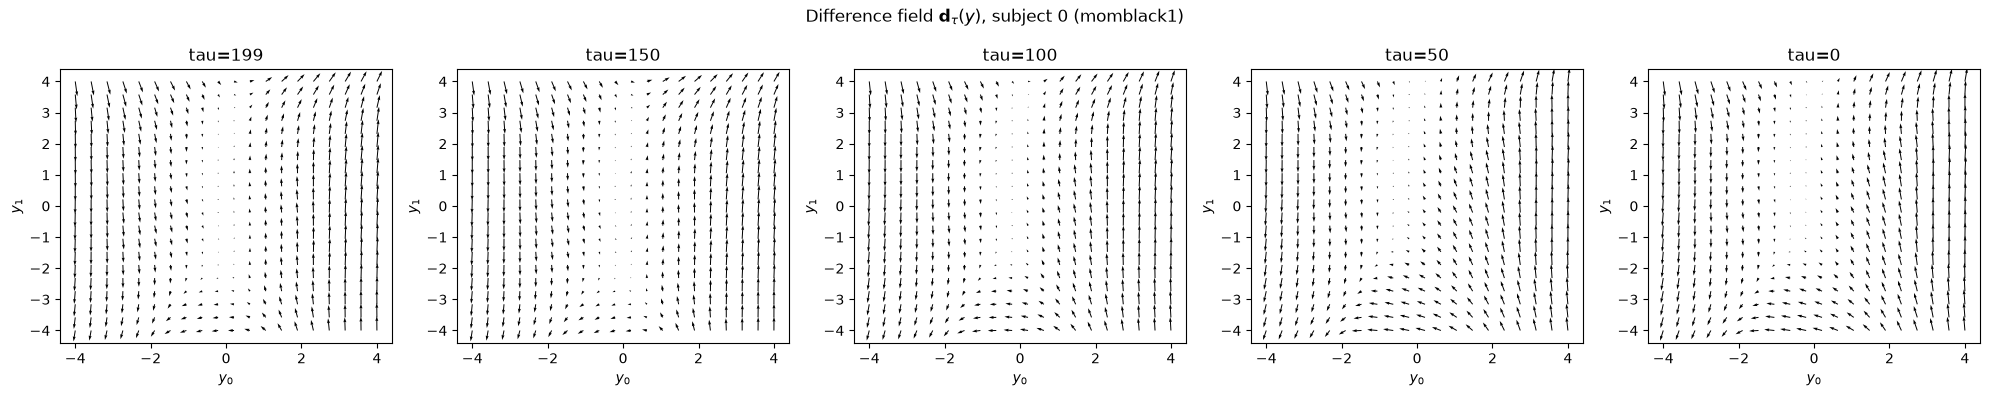

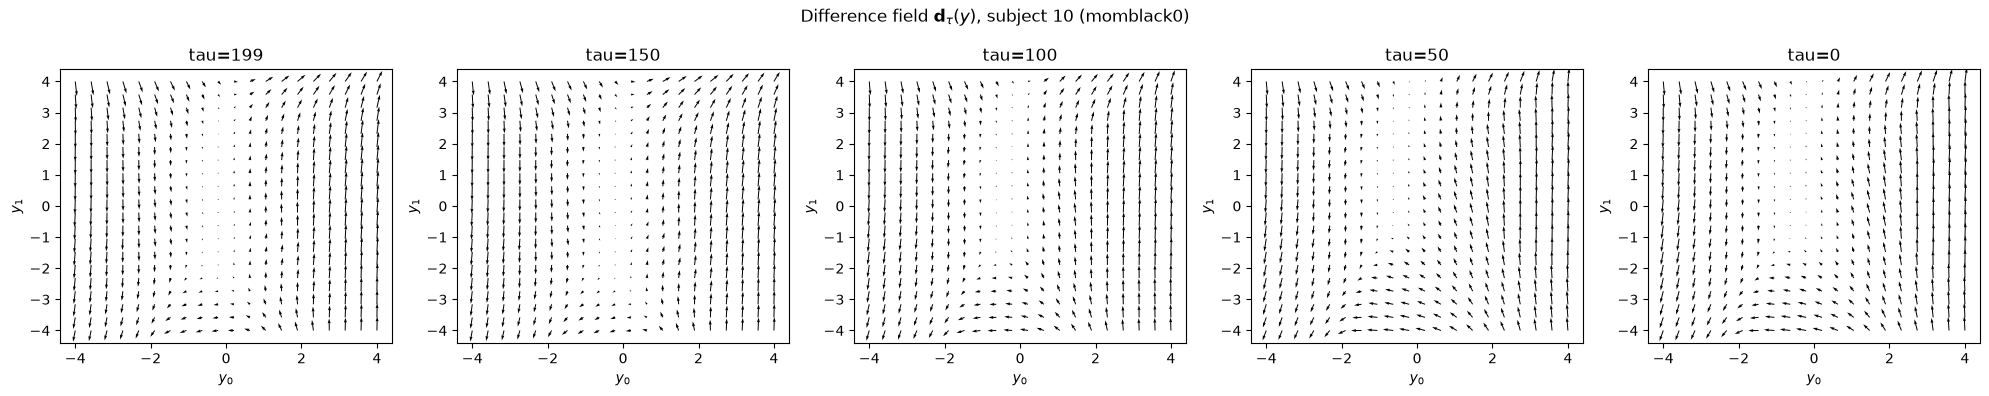

In [24]:
def plot_difference_field(
    tau: int, x_subj: torch.Tensor, a_anchor_subj: torch.Tensor, title: str, ax: Axes
):
    """Standalone difference field d_tau(y), both terms evaluated with the same
    (anchor) a -- here a_clean, matching d_tau's convention in Task 5 (spec: Two
    comparisons, B). Kept as raw eps_theta, not rescaled to the score (spec: Terminology)."""
    Y0, Y1, eps0_clean, eps1_clean = eps_grid(
        clean_model, tau, x_subj, a_anchor_subj, grid_n=GRID_N // 2
    )
    _, _, eps0_conf, eps1_conf = eps_grid(
        conf_model, tau, x_subj, a_anchor_subj, grid_n=GRID_N // 2
    )
    d0, d1 = eps0_conf - eps0_clean, eps1_conf - eps1_clean

    ax.quiver(Y0, Y1, d0, d1)
    ax.set_title(title)
    ax.set_xlabel(r"$y_0$")
    ax.set_ylabel(r"$y_1$")


for subj_idx, subj_label in [(subject_flipped, "momblack1"), (subject_control, "momblack0")]:
    x_subj, a_clean_subj = x[subj_idx], a_clean[subj_idx]

    fig, axes = plt.subplots(1, len(SNAPSHOT_TAUS), figsize=(4 * len(SNAPSHOT_TAUS), 4))
    for ax, tau in zip(axes, SNAPSHOT_TAUS, strict=True):
        plot_difference_field(tau, x_subj, a_clean_subj, f"tau={tau}", ax)
    fig.suptitle(
        rf"Difference field $\mathbf{{d}}_\tau(y)$, subject {subj_idx} ({subj_label})"
    )
    fig.tight_layout()
    fig.savefig(f"images/confounding_diff_field_{subj_label}.png", dpi=150)
    plt.show()